In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import butter, lfilter

In [30]:
# 1. Generating a Signal
# Let's create a simple sine wave
sampling_rate = 200  # Samples per second
duration = 1          # Seconds
frequency = 5         # Hz

t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
signal = np.sin(2 * np.pi * frequency * t)

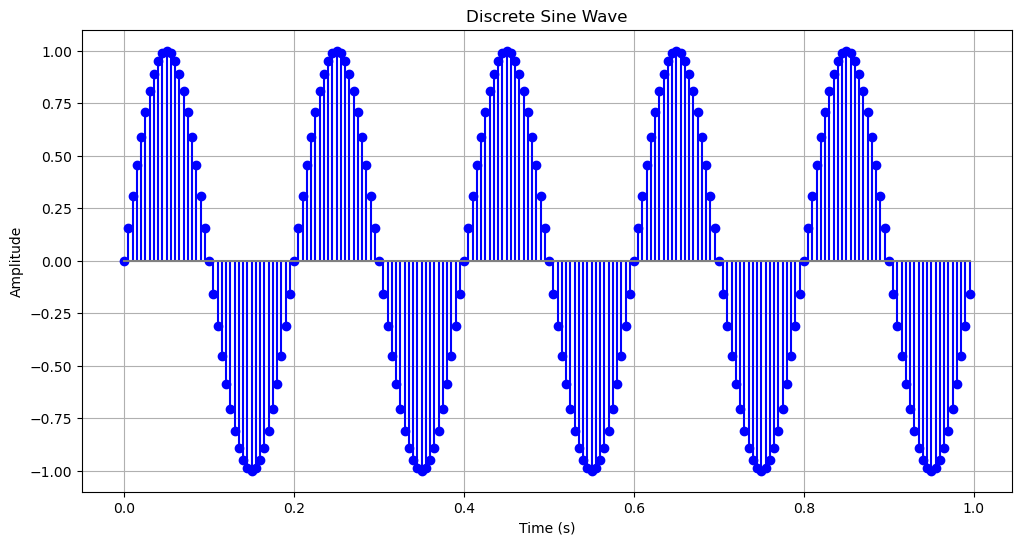

In [31]:
# 2. Time Domain Analysis
# Plotting the signal
plt.figure(figsize=(12, 6))
plt.stem(t, signal, linefmt='blue', markerfmt='bo', basefmt='gray')
plt.title('Discrete Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

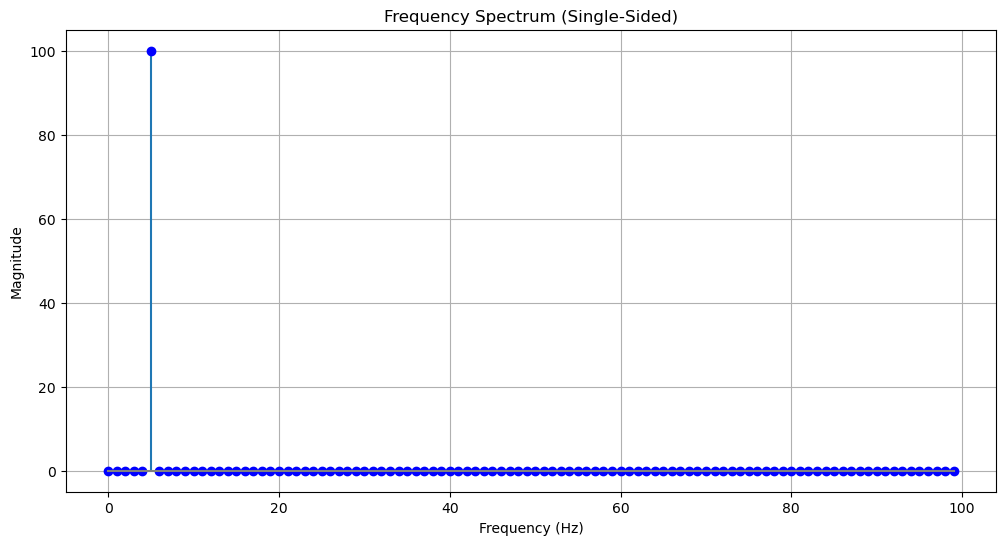

In [32]:
# 3. Frequency Domain Analysis (Fourier Transform)
# Applying FFT
fft_result = fft(signal)
frequencies = np.fft.fftfreq(signal.size, d=1/sampling_rate)

# Plotting the frequency spectrum
plt.figure(figsize=(12, 6))
plt.stem(frequencies[:signal.size//2], np.abs(fft_result[:signal.size//2]), markerfmt='bo', basefmt='gray') # Plot only positive frequencies
plt.title('Frequency Spectrum (Single-Sided)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()


# Inverse FFT to reconstruct the signal (optional)
reconstructed_signal = ifft(fft_result)

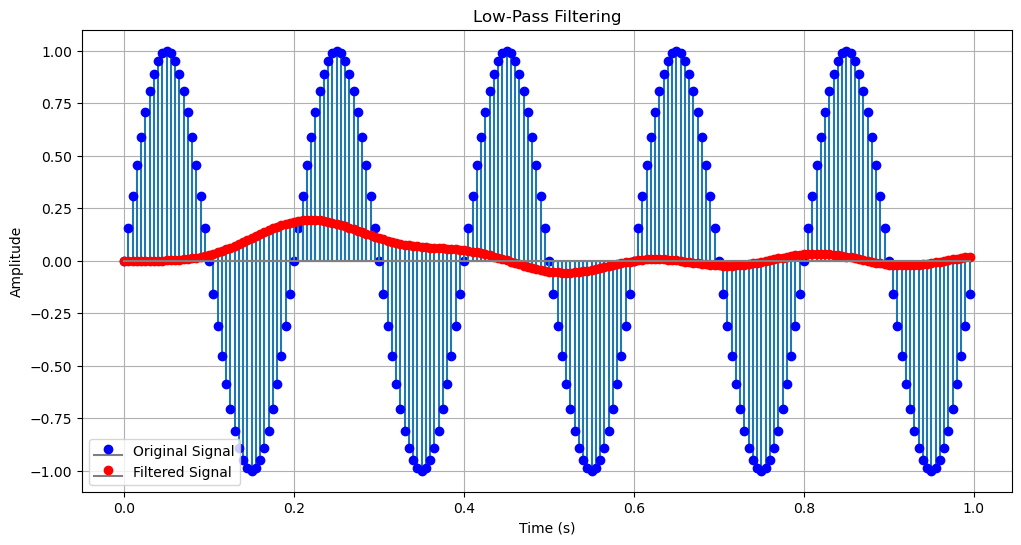

In [33]:
# 4. Filtering (Example: Low-Pass Butterworth Filter)
# Design a Butterworth filter
order = 4
cutoff_frequency = 2  # Hz
nyquist = 0.5 * sampling_rate  # Nyquist frequency
b, a = butter(order, cutoff_frequency / nyquist, 'low')

# Apply the filter
filtered_signal = lfilter(b, a, signal)

# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.stem(t, signal, label='Original Signal',markerfmt='bo', basefmt='gray')
plt.stem(t, filtered_signal, label='Filtered Signal', markerfmt='ro', basefmt='gray')
plt.title('Low-Pass Filtering')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# 5. Other common operations
#   - Convolution: scipy.signal.convolve
#   - Correlation: scipy.signal.correlate
#   - Windowing: scipy.signal.windows (e.g., hamming, hanning) - reduces spectral leakage.
